# P0 — GroupNorm pilot: `unet`, `unet_v2`

Round 0 of `fixing.md`'s retrain plan: validates finding #1 (`BatchNorm` at
`BATCH_SIZE=8` — well below the 50-256 range two lectures cite as typical)
on the two simplest deterministic architectures before rolling the change
out to the rest of the checkpoint tree in Round 1.

`scripts/unet.py` and `scripts/unet_v2.py` now build with
`GroupNormalization(groups=32)` in place of every `BatchNormalization`
(`_num_groups` adapts the group count down for smaller channel counts, e.g.
in unit tests — it stays 32 for this project's real channel sizes,
64-1024). This notebook trains both architectures fresh under that new
architecture and compares them against the existing BatchNorm checkpoints
in `models/deterministic/` (backed up separately in `models/pf1/` before
this branch started) — same test set, same loss, same everything except
the normalization layer.

New checkpoints save to `models/p0_groupnorm_pilot/<arch>/best_model.keras`
— a separate directory from `models/deterministic/`, so the baseline
checkpoints are never overwritten and remain available for this
comparison (and for the rest of the project) regardless of this pilot's
outcome.

Make the project root importable so `scripts.*` resolves regardless of
the notebook's working directory.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed, and a GPU sanity check — same as
`020_training.ipynb`.

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.trainer import compile_model, get_callbacks, get_model, load_model
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.16.2


## 1. Dataset — artwork-and-mockups split

Same split every training/evaluation notebook in the project uses (see
`notebooks/010_eda.ipynb` for the leakage-integrity check on it).

In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, test_pairs = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)
test_ds = build_dataset(
    test_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")
print(f"Test:  {len(test_pairs)} patches ({len(test_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)
Test:  135 patches (17 batches)


2026-08-24 21:59:39.252591: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-24 21:59:39.252619: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-24 21:59:39.252627: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-24 21:59:39.252638: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-24 21:59:39.252647: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Train `unet` and `unet_v2` with GroupNorm

Both use `combined_loss` (MAE + (1 - SSIM)) via `compile_model` —
unchanged from `020_training.ipynb`; the only thing that changed is what
`get_model` builds. Checkpoints go to
`models/p0_groupnorm_pilot/<arch>/best_model.keras`, keeping
`models/deterministic/` (the BatchNorm baseline) untouched. Set `EPOCHS`
lower for a quick smoke test before committing to a full run.

In [4]:
ARCHS = ["unet", "unet_v2"]
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
MODEL_DIR = settings.MODELS_DIR / "p0_groupnorm_pilot"
LOG_DIR = settings.LOGS_DIR / "p0_groupnorm_pilot"

histories: dict = {}

for arch in ARCHS:
    print(f"\n{'=' * 60}")
    print(f"  Architecture: {arch} (GroupNorm)")
    print(f"{'=' * 60}")

    model = get_model(arch)
    model = compile_model(
        model, arch, lr=settings.LEARNING_RATE, loss_alpha=settings.LOSS_ALPHA
    )
    model.summary(line_length=80)

    callbacks = get_callbacks(arch, log_dir=LOG_DIR, model_dir=MODEL_DIR)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )
    histories[arch] = history.history

    best_val_loss = min(history.history["val_loss"])
    print(f"\nBest val_loss ({arch}, GroupNorm): {best_val_loss:.4f}")


  Architecture: unet (GroupNorm)


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, None,      │       1,728 │ input_layer[0][0]  │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization   │ (None, None,      │         128 │ conv2d[0][0]       │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu (ReLU)          │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, None,      │      36,864 │ re_lu[0][0]        │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_1 │ (None, None,      │         128 │ conv2d_1[0][0]     │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_1 (ReLU)        │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, None,      │           0 │ re_lu_1[0][0]      │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, None,      │      73,728 │ max_pooling2d[0][… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_2 │ (None, None,      │         256 │ conv2d_2[0][0]     │
│ (GroupNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_2 (ReLU)        │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, None,      │     147,456 │ re_lu_2[0][0]      │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_3 │ (None, None,      │         256 │ conv2d_3[0][0]     │
│ (GroupNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_3 (ReLU)        │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_1       │ (None, None,      │           0 │ re_lu_3[0][0]      │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_4 (Conv2D)     │ (None, None,      │     294,912 │ max_pooling2d_1[0… │
│                       │ None,

 Total params: 31,037,633 (118.40 MB)

 Trainable params: 31,037,633 (118.40 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, None,      │           0 │ -                  │
│ (InputLayer)          │ None, 3)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_19 (Conv2D)    │ (None, None,      │       1,728 │ input_layer_1[0][… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_… │ (None, None,      │         128 │ conv2d_19[0][0]    │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_18 (ReLU)       │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_20 (Conv2D)    │ (None, None,      │      36,864 │ re_lu_18[0][0]     │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_… │ (None, None,      │         128 │ conv2d_20[0][0]    │
│ (GroupNormalization)  │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_19 (ReLU)       │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_4       │ (None, None,      │           0 │ re_lu_19[0][0]     │
│ (MaxPooling2D)        │ None, 64)         │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_21 (Conv2D)    │ (None, None,      │      73,728 │ max_pooling2d_4[0… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_… │ (None, None,      │         256 │ conv2d_21[0][0]    │
│ (GroupNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_20 (ReLU)       │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_22 (Conv2D)    │ (None, None,      │     147,456 │ re_lu_20[0][0]     │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ group_normalization_… │ (None, None,      │         256 │ conv2d_22[0][0]    │
│ (GroupNormalization)  │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_21 (ReLU)       │ (None, None,      │           0 │ group_normalizati… │
│                       │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d_5       │ (None, None,      │           0 │ re_lu_21[0][0]     │
│ (MaxPooling2D)        │ None, 128)        │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_23 (Conv2D)    │ (None, None,      │     294,912 │ max_pooling2d_5[0… │
│                       │ None,

 Total params: 31,037,633 (118.40 MB)

 Trainable params: 31,037,633 (118.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - loss: 0.2742 - mae: 0.1739 - psnr: 15.7627 - ssim: 0.4919
Epoch 1: val_loss improved from None to 0.23144, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/p0_groupnorm_pilot/unet_v2/best_model.keras

Epoch 1: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/p0_groupnorm_pilot/unet_v2/best_model.keras
108/108 ━━━━━━━━━━━━━━━━━━━━ 105s 921ms/step - loss: 0.2742 - mae: 0.1739 - psnr: 15.7627 - ssim: 0.4919 - val_loss: 0.2314 - val_mae: 0.1769 - val_psnr: 15.6493 - val_ssim: 0.6413 - learning_rate: 1.0000e-04
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - loss: 0.2225 - mae: 0.1429 - psnr: 17.7562 - ssim: 0.5916
Epoch 2: val_loss improved from 0.23144 to 0.20514, saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/p0_groupnorm_pilot/unet_v2/best_model.keras

Epoch 2: finished saving model to /Users/simonecaglio/Documents/GitHub/deep_layers/models/p0

## 3. Training curves

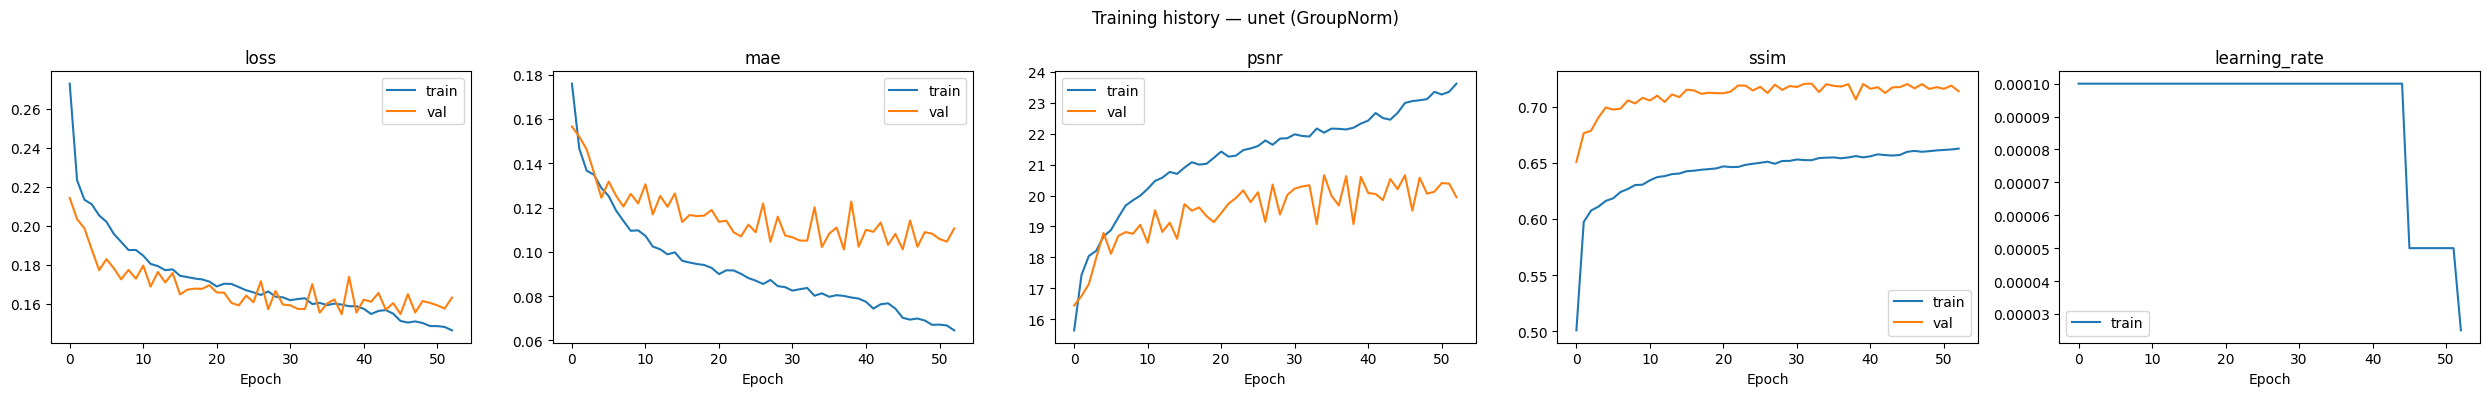

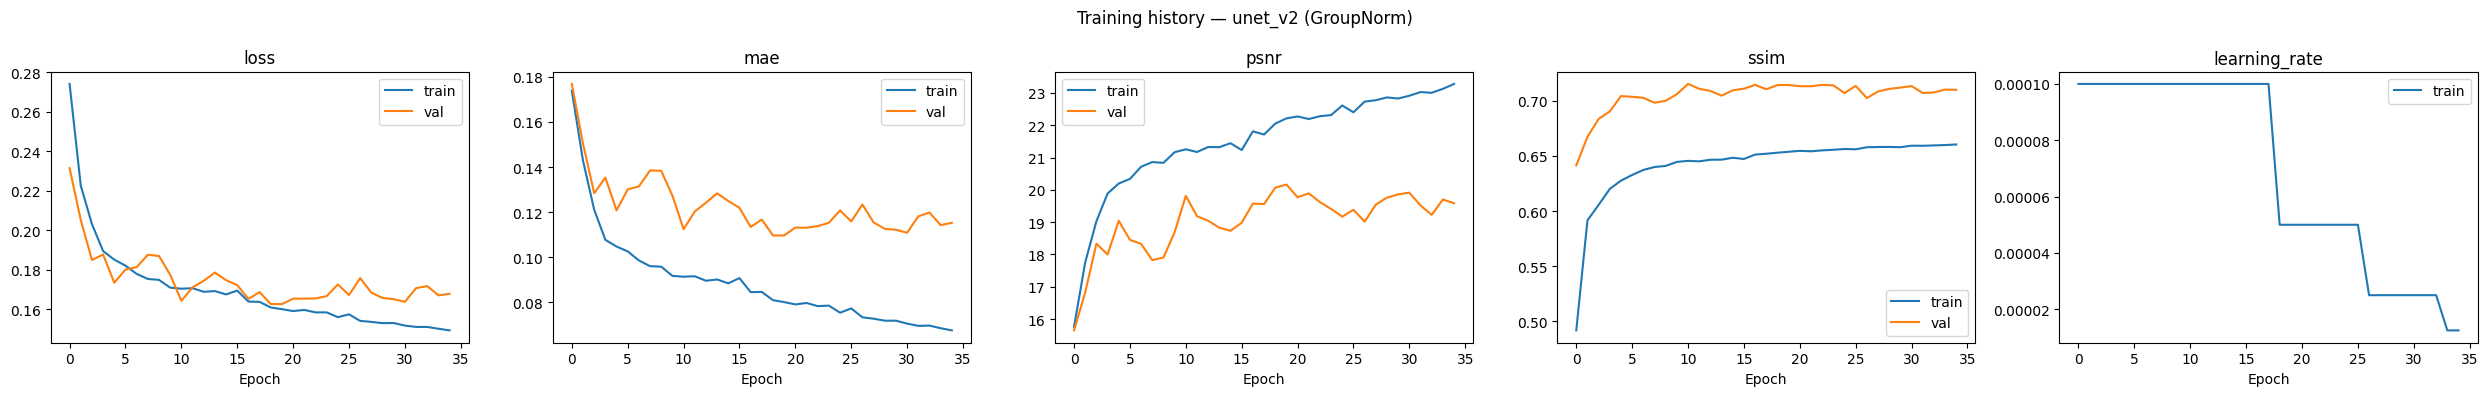

In [5]:
for arch, history in histories.items():
    plot_training_curves(history, title=f"Training history — {arch} (GroupNorm)")
    plt.show()

## 4. Evaluate on the test set — GroupNorm pilot vs. BatchNorm baseline

Loads the freshly trained GroupNorm checkpoints from
`models/p0_groupnorm_pilot/` alongside the existing BatchNorm checkpoints
from `models/deterministic/` (unchanged by this notebook), so both sit in
the same comparison table. A missing checkpoint on either side is skipped,
not treated as an error.

In [6]:
BASELINE_DIR = settings.MODELS_DIR / "deterministic"
PILOT_DIR = settings.MODELS_DIR / "p0_groupnorm_pilot"

results: dict = {}

for arch in ARCHS:
    for label, model_dir in [("baseline (BatchNorm)", BASELINE_DIR), ("pilot (GroupNorm)", PILOT_DIR)]:
        key = f"{arch} — {label}"
        try:
            model = load_model(
                arch,
                model_dir=model_dir,
                lr=settings.LEARNING_RATE,
                loss_alpha=settings.LOSS_ALPHA,
            )
        except FileNotFoundError as exc:
            print(f"[skip] {exc}")
            continue

        print(f"Evaluating {key}...")
        metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
        results[key] = metrics
        print(f"  {key}: { {k: f'{v:.4f}' for k, v in metrics.items()} }")

Evaluating unet — baseline (BatchNorm)...
  unet — baseline (BatchNorm): {'loss': '0.2127', 'mae': '0.1105', 'psnr': '18.6442', 'ssim': '0.5489'}
Evaluating unet — pilot (GroupNorm)...
  unet — pilot (GroupNorm): {'loss': '0.1964', 'mae': '0.1026', 'psnr': '19.3462', 'ssim': '0.5846'}
Evaluating unet_v2 — baseline (BatchNorm)...
  unet_v2 — baseline (BatchNorm): {'loss': '0.1944', 'mae': '0.1030', 'psnr': '19.4879', 'ssim': '0.5922'}
Evaluating unet_v2 — pilot (GroupNorm)...
  unet_v2 — pilot (GroupNorm): {'loss': '0.1966', 'mae': '0.1035', 'psnr': '19.2422', 'ssim': '0.5861'}


## 5. Comparison table

In [10]:
if results:
    col_w = 35
    headers = ["model"] + list(next(iter(results.values())).keys())
    print("".join(h.ljust(col_w) for h in headers))
    print("-" * (col_w * len(headers)))
    for key, metrics in results.items():
        row = [key] + [f"{v:.4f}" for v in metrics.values()]
        print("".join(c.ljust(col_w) for c in row))

model                              loss                               mae                                psnr                               ssim                               
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
unet — baseline (BatchNorm)        0.2127                             0.1105                             18.6442                            0.5489                             
unet — pilot (GroupNorm)           0.1964                             0.1026                             19.3462                            0.5846                             
unet_v2 — baseline (BatchNorm)     0.1944                             0.1030                             19.4879                            0.5922                             
unet_v2 — pilot (GroupNorm)        0.1966                             0.1035                             19.2422        

## 6. Bar chart comparison

/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_24491/1316865172.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=30, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_24491/1316865172.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=30, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_24491/1316865172.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(keys, rotation=30, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_24491/1316865172.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


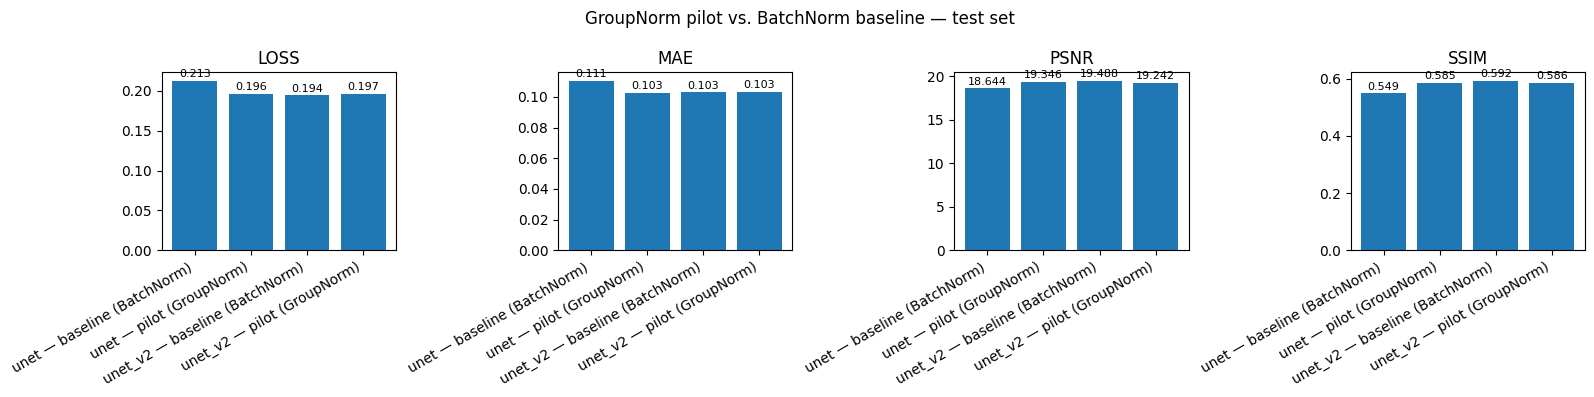

In [8]:
if results:
    metric_keys = list(next(iter(results.values())).keys())
    n = len(metric_keys)
    keys = list(results.keys())
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle("GroupNorm pilot vs. BatchNorm baseline — test set")
    for ax, metric in zip(axes, metric_keys):
        vals = [results[k][metric] for k in keys]
        bars = ax.bar(keys, vals)
        ax.set_title(metric.upper())
        ax.set_xticklabels(keys, rotation=30, ha="right")
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## 7. Summary

Pilot checkpoints saved to `models/p0_groupnorm_pilot/<arch>/best_model.keras`.
Logs written to `logs/p0_groupnorm_pilot/<arch>/`.

**Reading the result**: if `unet`/`unet_v2` (GroupNorm) matches or beats
`unet`/`unet_v2` (BatchNorm baseline) on `mae`/`ssim`/`psnr`, Round 1 of
`fixing.md` proceeds — rolling `GroupNormalization` out to the rest of the
checkpoint tree (`resunet`, `attention_unet`, plus every `_nll` variant)
combined with the other Round 1 changes (weight decay, He init, ResUNet
identity shortcut). If it regresses, that is worth understanding before
committing the same change to 10 more checkpoints — see `fixing.md` §2 for
the full round plan.

In [9]:
for arch in ARCHS:
    ckpt = MODEL_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}: {status}  ({ckpt})")

unet                     : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/p0_groupnorm_pilot/unet/best_model.keras)
unet_v2                  : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/p0_groupnorm_pilot/unet_v2/best_model.keras)
